# Fourier Analysis of Biological Signals


Biological systems often produce signals that change with time:

- the heartbeat,
- breathing,
- brain activity,
- walking and other periodic movements,
- daily biological rhythms,
- oscillating populations.

Sometimes the rhythm is obvious when we plot the signal against time. Sometimes several rhythms are superimposed and the signal becomes difficult to interpret.

In this notebook we will learn how **Fourier analysis** can reveal the frequencies hidden in a time-dependent signal.

### Learning goals

After working through this notebook, you should be able to:

- describe a sinusoidal signal by amplitude, frequency, period, and phase,
- convert between frequency and period,
- understand the idea of decomposing a signal into oscillations,
- calculate a Fourier spectrum numerically,
- identify dominant frequencies in biological signals,
- understand why the mean value produces a zero-frequency component,
- understand the effects of signal duration and sampling,
- interpret harmonics,
- apply Fourier analysis to a biological oscillator.

# Biological rhythms

Consider a resting heart rate of 72 beats per minute.

How many beats per second is this?

$$
f=\frac{72}{60}\,\mathrm{Hz}=1.2\,\mathrm{Hz}.
$$

The corresponding period is

$$
T=\frac{1}{f}.
$$

Thus a frequency and a period contain the same information:

$$
\boxed{f=\frac{1}{T}}.
$$

Frequency is measured in hertz:

$$
1\,\mathrm{Hz}=1\,\mathrm{s}^{-1}.
$$

In [ ]:
heart_rate_bpm = 72

f_heart = heart_rate_bpm / 60
T_heart = 1 / f_heart

print(f"Heart frequency = {f_heart:.2f} Hz")
print(f"Period = {T_heart:.3f} s")

### Exercise 1 — biological frequencies

Calculate the frequency and period for:

1. a heart rate of 60 beats/min,
2. a heart rate of 90 beats/min,
3. a breathing rate of 15 breaths/min.

Which process has the longer characteristic time scale: heartbeat or breathing?

# The simplest periodic signal

A sinusoidal signal can be written as

$$
y(t)=A\sin(2\pi f t+\phi).
$$

Here:

- $A$ is the amplitude,
- $f$ is the frequency,
- $T=1/f$ is the period,
- $\phi$ is the phase.

Let us first generate a simple signal with a frequency of 1.2 Hz.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fs = 100               # samples per second
duration = 10          # seconds
t = np.arange(0, duration, 1/fs)

f = 1.2
A = 1.0

signal = A*np.sin(2*np.pi*f*t)

plt.plot(t, signal)
plt.xlabel("time (s)")
plt.ylabel("signal")
plt.title("A sinusoidal biological rhythm: 1.2 Hz")
plt.grid()
plt.show()

### Exercise 2 — changing a sinusoid

Modify the code above.

1. Change the frequency from 1.2 Hz to 2 Hz.
2. Change the amplitude from 1 to 2.
3. Add a phase shift $\phi=\pi/2$.
4. Which changes affect the period?
5. Which changes affect only the vertical scale or starting point?

# A more realistic biological question

Suppose we record a signal from a person.

The signal contains:

- a heartbeat at 72 beats/min,
- a respiratory rhythm at 15 breaths/min.

The corresponding frequencies are

$$
f_{\mathrm{heart}}=1.2\,\mathrm{Hz}
$$

and

$$
f_{\mathrm{breathing}}=0.25\,\mathrm{Hz}.
$$

Imagine that our measured signal is influenced by both processes:

$$
y(t)
=
\sin(2\pi f_{\mathrm{heart}}t)
+
0.3\sin(2\pi f_{\mathrm{breathing}}t).
$$

In [ ]:
f_heart = 1.2
f_breath = 0.25

heart = np.sin(2*np.pi*f_heart*t)
breathing = 0.3*np.sin(2*np.pi*f_breath*t)

combined = heart + breathing

plt.plot(t, heart, label="heartbeat component")
plt.plot(t, breathing, label="breathing component")
plt.xlabel("time (s)")
plt.ylabel("signal")
plt.title("Two biological rhythms")
plt.legend()
plt.grid()
plt.show()

plt.plot(t, combined)
plt.xlabel("time (s)")
plt.ylabel("measured signal")
plt.title("Heartbeat and breathing superimposed")
plt.grid()
plt.show()

The combined signal is already more difficult to interpret.

If we did not know how it had been constructed, how could we determine which rhythms are present?

This motivates a different way of looking at a signal.

Instead of asking

> **How does the signal change with time?**

we ask

> **Which frequencies are contained in the signal?**

This is the central idea of **Fourier analysis**.

# From the time domain to the frequency domain
The ordinary plot

$$
y(t)
$$

shows the signal in the **time domain**.

Fourier analysis transforms this into a representation showing how strongly different frequencies contribute to the signal.

We can think of this schematically as

$$
\boxed{
\text{signal versus time}
\quad\longrightarrow\quad
\text{amplitude versus frequency}
}
$$

A pure sine wave should therefore produce one dominant frequency.

In [ ]:
# Fourier transform of the pure heartbeat signal

Y = np.fft.rfft(heart)
freq = np.fft.rfftfreq(len(heart), d=1/fs)

amplitude = 2*np.abs(Y)/len(heart)

plt.plot(freq, amplitude)
plt.xlim(0, 5)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Fourier spectrum of a 1.2 Hz sine wave")
plt.grid()
plt.show()

The time-domain signal oscillates continuously, but its Fourier spectrum has a peak at

$$
f=1.2\,\mathrm{Hz}.
$$

Fourier analysis has identified the rhythm.

For a real-valued signal we only need to display positive frequencies, which is why we use `rfft` in Python.

# Finding two biological rhythms
Now let us Fourier-transform the signal containing both heartbeat and respiration.

In [ ]:
Y = np.fft.rfft(combined)
freq = np.fft.rfftfreq(len(combined), d=1/fs)

amplitude = 2*np.abs(Y)/len(combined)

plt.plot(freq, amplitude)
plt.xlim(0, 3)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Fourier spectrum: heartbeat + respiration")
plt.grid()
plt.show()

We now see two peaks.

One occurs near

$$
0.25\,\mathrm{Hz},
$$

corresponding to

$$
0.25\times60=15
$$

breaths per minute.

The other occurs near

$$
1.2\,\mathrm{Hz},
$$

corresponding to

$$
1.2\times60=72
$$

beats per minute.

A complicated-looking time signal has become much easier to interpret in the frequency domain.

### Exercise 3 — identify an unknown rhythm

The following cell generates a signal containing two biological rhythms.

Run the cell, inspect the time trace, and then calculate its Fourier spectrum.

Determine both frequencies and express them as events per minute.

In [ ]:
# Unknown signal for the exercise

f1 = 0.30
f2 = 1.50

unknown_signal = (
    0.4*np.sin(2*np.pi*f1*t) +
    1.0*np.sin(2*np.pi*f2*t)
)

plt.plot(t, unknown_signal)
plt.xlabel("time (s)")
plt.ylabel("signal")
plt.title("Unknown biological signal")
plt.grid()
plt.show()

# Add your Fourier-transform code below.

# What happens when measurements contain noise?
Real biological measurements are never perfectly clean.

Let us add random noise to our heartbeat + breathing signal.

In [ ]:
rng = np.random.default_rng(4)

noise = 0.6*rng.normal(size=len(t))
noisy_signal = combined + noise

plt.plot(t, noisy_signal)
plt.xlabel("time (s)")
plt.ylabel("measured signal")
plt.title("Biological signal with noise")
plt.grid()
plt.show()

It is now considerably harder to identify the two rhythms by looking at the time trace.

Let us calculate its spectrum.

In [ ]:
Y = np.fft.rfft(noisy_signal - np.mean(noisy_signal))
freq = np.fft.rfftfreq(len(noisy_signal), d=1/fs)

amplitude = 2*np.abs(Y)/len(noisy_signal)

plt.plot(freq, amplitude)
plt.xlim(0, 3)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Fourier spectrum of the noisy signal")
plt.grid()
plt.show()

Even though the time signal is noisy, the two characteristic frequencies remain visible.

This is one reason Fourier analysis is so useful in experimental biology and medicine.

# The mathematics behind the Fourier transform

Before asking Python to calculate a Fourier transform, let us calculate some simple examples ourselves.

We use the convention

$$
F(\omega)=\int_{-\infty}^{\infty}f(t)e^{-i\omega t}\,dt.
$$

Using Euler's formula,

$$
e^{-i\omega t}=\cos(\omega t)-i\sin(\omega t),
$$

we can interpret this as comparing the signal with oscillations of angular frequency $\omega$.

Remember:

$$
\omega=2\pi f.
$$

## 4.1 A sinusoidal signal

Consider

$$
f(t)=\cos(\omega_0t).
$$

Using

$$
\cos(\omega_0t)
=
\frac{1}{2}
\left(
e^{i\omega_0t}+e^{-i\omega_0t}
\right),
$$

we see immediately that the cosine contains two complex oscillations:

$$
+\omega_0
\qquad\text{and}\qquad
-\omega_0.
$$

For an infinitely long cosine, its Fourier transform consists of two infinitely sharp peaks:

$$
F(\omega)
=
\pi\left[
\delta(\omega-\omega_0)
+
\delta(\omega+\omega_0)
\right].
$$

The symbol $\delta$ is the **Dirac delta function**. We do not need to study it in detail here. It simply represents an ideal infinitely narrow spectral peak.

For a sine,

$$
\sin(\omega_0t)
=
\frac{1}{2i}
\left(
e^{i\omega_0t}-e^{-i\omega_0t}
\right),
$$

so again only the frequencies $+\omega_0$ and $-\omega_0$ occur.

For real experimental signals we usually plot only the positive-frequency part of the spectrum.

### But experiments never last forever

An infinitely long sine wave is an idealization.

Suppose we observe

$$
f(t)=\cos(\omega_0t)
$$

only during a finite time interval.

The spectral peak is then no longer infinitely narrow. This is exactly what happens in a numerical Fourier transform of a finite recording.

We will return to this important point after considering an even simpler signal: a single rectangular pulse.

## 4.2 Fourier transform of a rectangular pulse

Consider a pulse of duration $T$:

$$
p(t)=
\begin{cases}
1, & -T/2<t<T/2,\\
0, & \text{otherwise}.
\end{cases}
$$

Its Fourier transform is

$$
P(\omega)
=
\int_{-\infty}^{\infty}
p(t)e^{-i\omega t}\,dt.
$$

Since $p(t)=0$ outside the pulse, this becomes

$$
P(\omega)
=
\int_{-T/2}^{T/2}
e^{-i\omega t}\,dt.
$$

We can integrate directly:

$$
P(\omega)
=
\left[
\frac{e^{-i\omega t}}{-i\omega}
\right]_{-T/2}^{T/2}.
$$

Therefore

$$
P(\omega)
=
\frac{
e^{-i\omega T/2}-e^{i\omega T/2}
}
{-i\omega}.
$$

Using

$$
e^{ix}-e^{-ix}=2i\sin x,
$$

we obtain

$$
\boxed{
P(\omega)
=
\frac{2\sin(\omega T/2)}{\omega}
}.
$$

Equivalently,

$$
\boxed{
P(\omega)
=
T\,\mathrm{sinc}\left(\frac{\omega T}{2}\right)
}
$$

if we define

$$
\mathrm{sinc}(x)=\frac{\sin x}{x}.
$$

### What does the result mean?

At $\omega=0$ the expression appears to contain $0/0$, but

$$
\lim_{x\rightarrow0}\frac{\sin x}{x}=1.
$$

Therefore

$$
P(0)=T.
$$

This also makes intuitive sense: at zero frequency,

$$
P(0)=\int p(t)\,dt,
$$

which is simply the **area of the pulse**.

The zeros of the spectrum occur when

$$
\frac{\omega T}{2}=\pm\pi,\pm2\pi,\ldots
$$

The first zeros are therefore at

$$
\omega=\pm\frac{2\pi}{T}.
$$

Since $\omega=2\pi f$,

$$
\boxed{f=\pm\frac{1}{T}}.
$$

Thus a shorter pulse produces a broader Fourier spectrum.

In [ ]:
# Analytical spectrum of rectangular pulses

f = np.linspace(-10, 10, 2000)

for T in [0.5, 1.0, 2.0]:
    # np.sinc(x) in NumPy means sin(pi*x)/(pi*x).
    # P(f) = T sinc(f*T) when frequency f is measured in Hz.
    P = T * np.sinc(f*T)
    plt.plot(f, np.abs(P), label=f"T = {T} s")

plt.xlabel("frequency f (Hz)")
plt.ylabel("|P(f)|")
plt.title("Fourier transform of rectangular pulses")
plt.legend()
plt.grid()
plt.show()

The figure demonstrates one of the most important ideas in Fourier analysis:

$$
\boxed{
\text{short in time}
\quad\Longleftrightarrow\quad
\text{broad in frequency}
}
$$

and conversely,

$$
\boxed{
\text{long in time}
\quad\Longleftrightarrow\quad
\text{narrow in frequency}.
}
$$

Very roughly,

$$
\Delta t\,\Delta f\sim1.
$$

The exact numerical factor depends on how the widths are defined.

### Exercise — pulse width and spectral width

For rectangular pulses with

$$
T=0.25,\quad0.5,\quad1,\quad2\ \mathrm{s},
$$

1. plot the pulses in the time domain,
2. calculate their Fourier spectra,
3. determine the frequency of the first zero,
4. compare it with the prediction

$$
f_{\mathrm{zero}}=\frac{1}{T}.
$$

Complete the table:

| $T$ (s) | first zero (Hz) |
|---:|---:|
| 0.25 | |
| 0.50 | |
| 1.00 | |
| 2.00 | |

What happens to the spectrum when the pulse becomes shorter?

## 4.3 A finite-duration sinusoid

We can now understand what happens when we observe a sinusoid for only a finite time.

Mathematically, we multiply an infinitely long sinusoid by a rectangular observation window:

$$
f_{\mathrm{measured}}(t)
=
\cos(\omega_0t)\,p(t).
$$

The finite observation time broadens the ideal spectral peak.

Let us see this numerically.

In [ ]:
f0 = 2.0
fs_demo = 200

for Tobs in [1, 2, 5]:
    tt = np.arange(-Tobs/2, Tobs/2, 1/fs_demo)
    yy = np.cos(2*np.pi*f0*tt)

    YY = np.fft.fftshift(np.fft.fft(yy))
    ff = np.fft.fftshift(np.fft.fftfreq(len(yy), d=1/fs_demo))

    amplitude = np.abs(YY)/len(yy)
    plt.plot(ff, amplitude, label=f"observation = {Tobs} s")

plt.xlim(-5, 5)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Finite observation time broadens a sinusoidal spectral peak")
plt.legend()
plt.grid()
plt.show()

As the observation time becomes longer, the peaks near

$$
f=\pm f_0
$$

become narrower.

In the ideal limit of an infinitely long observation, they approach the infinitely sharp delta-function peaks discussed above.

# Why do we subtract the mean?
Biological signals often have a non-zero average value.

Suppose we add a constant offset:

$$
y_{\mathrm{offset}}(t)=5+y(t).
$$

A constant does not oscillate. Its frequency is

$$
f=0.
$$

Therefore a non-zero mean appears as a large peak at zero frequency.

In [ ]:
offset_signal = 5 + combined

Y1 = np.fft.rfft(offset_signal)
Y2 = np.fft.rfft(offset_signal - np.mean(offset_signal))

freq = np.fft.rfftfreq(len(offset_signal), d=1/fs)

plt.plot(freq, 2*np.abs(Y1)/len(offset_signal), label="with mean")
plt.plot(freq, 2*np.abs(Y2)/len(offset_signal), label="mean removed")
plt.xlim(0, 3)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("The mean value is the zero-frequency component")
plt.legend()
plt.grid()
plt.show()

For many applications we therefore calculate

```python
signal = signal - np.mean(signal)
```

before calculating the spectrum.

This removes the **DC component**, i.e. the component at $f=0$.

# A biological signal need not be sinusoidal
A heartbeat or pulse is not a perfect sine wave.

Let us create a simple pulse-like periodic signal by adding several sine waves:

$$
y(t)
=
\sin(2\pi f t)
+
0.5\sin(2\pi 2ft)
+
0.25\sin(2\pi 3ft).
$$

The frequencies $2f$, $3f$, ... are called **harmonics**.

In [ ]:
f0 = 1.2

pulse_like = (
    np.sin(2*np.pi*f0*t)
    + 0.5*np.sin(2*np.pi*2*f0*t)
    + 0.25*np.sin(2*np.pi*3*f0*t)
)

plt.plot(t, pulse_like)
plt.xlim(0, 4)
plt.xlabel("time (s)")
plt.ylabel("signal")
plt.title("A non-sinusoidal periodic signal")
plt.grid()
plt.show()

Y = np.fft.rfft(pulse_like)
freq = np.fft.rfftfreq(len(pulse_like), d=1/fs)

plt.plot(freq, 2*np.abs(Y)/len(pulse_like))
plt.xlim(0, 6)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Fundamental frequency and harmonics")
plt.grid()
plt.show()

The spectrum contains peaks at

$$
f_0,\quad 2f_0,\quad 3f_0.
$$

This illustrates an important principle:

> A periodic signal does not need to be sinusoidal. Its shape can be constructed from a fundamental frequency and harmonics.

The Fourier spectrum therefore contains information not only about the repetition rate but also about the shape of the repeating signal.

## From one pulse to a periodic pulse train

Many biological signals are not sinusoidal.

A heartbeat, a neuronal spike train, or repeated muscle activation can look more like a sequence of pulses.

If a pulse repeats every period $T_0$, its fundamental frequency is

$$
f_0=\frac{1}{T_0}.
$$

A periodic but non-sinusoidal signal can be represented as a sum of sine and cosine waves whose frequencies are integer multiples of $f_0$:

$$
f_0,\quad2f_0,\quad3f_0,\quad\ldots
$$

These are the **harmonics**.

## 4.5 Fourier series of a square wave

Consider a symmetric square wave with amplitude $+1$ and $-1$.

Its Fourier series is

$$
\boxed{
s(t)
=
\frac{4}{\pi}
\left[
\sin(\omega_0t)
+
\frac{1}{3}\sin(3\omega_0t)
+
\frac{1}{5}\sin(5\omega_0t)
+\cdots
\right]
}.
$$

Only **odd harmonics** occur:

$$
\omega_0,\quad3\omega_0,\quad5\omega_0,\ldots
$$

and their amplitudes decrease as

$$
1,\quad\frac13,\quad\frac15,\ldots
$$

This is a striking result: a signal with sharp edges can be constructed entirely from smooth sine waves.

In [29]:
# Interactive Fourier-series reconstruction of a square wave
# Requires ipywidgets (works with the XEUS kernel in JupyterLite).

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

t_square = np.linspace(0, 2, 2000)
f0_square = 1.0
omega0_square = 2 * np.pi * f0_square

def fourier_square(n_harmonics=1, show_components=True):
    y = np.zeros_like(t_square)

    # Add the odd Fourier components: n = 1, 3, 5, ...
    for k in range(n_harmonics):
        n = 2*k + 1
        y += (4 / (np.pi*n)) * np.sin(n * omega0_square * t_square)

    # Ideal square wave for comparison
    ideal = np.sign(np.sin(omega0_square * t_square))

    # --- Reconstruction in the time domain ---
    plt.figure(figsize=(9, 4))
    plt.plot(t_square, ideal, "--", linewidth=2, label="ideal square wave")
    plt.plot(t_square, y, linewidth=2, label="Fourier approximation")

    if show_components:
        for k in range(n_harmonics):
            n = 2*k + 1
            component = (4 / (np.pi*n)) * np.sin(n * omega0_square * t_square)
            plt.plot(t_square, component, alpha=0.4, linewidth=1)

    plt.xlabel("time (s)")
    plt.ylabel("signal")
    plt.title(f"Square wave reconstructed from {n_harmonics} odd harmonics")
    plt.xlim(0, 2)
    plt.ylim(-1.6, 1.6)
    plt.grid()
    plt.legend()
    plt.show()

    # --- Fourier coefficients ---
    n = np.arange(1, 2*n_harmonics, 2)
    amplitudes = 4 / (np.pi*n)

    plt.figure(figsize=(9, 3))
    plt.stem(n, amplitudes)
    plt.xlabel("harmonic number n")
    plt.ylabel("amplitude")
    plt.title(r"Fourier coefficients: $A_n=4/(\pi n)$ for odd $n$")
    plt.xlim(0, max(10, 2*n_harmonics))
    plt.ylim(0, 1.4)
    plt.grid()
    plt.show()

harmonics_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=30,
    step=1,
    description="Harmonics:",
    continuous_update=True
)

components_checkbox = widgets.Checkbox(
    value=True,
    description="Show components"
)

widgets.interact(
    fourier_square,
    n_harmonics=harmonics_slider,
    show_components=components_checkbox
);

interactive(children=(IntSlider(value=1, description='Harmonics:', max=30, min=1), Checkbox(value=True, descri…

Notice that adding more harmonics makes the transitions increasingly sharp.

Near the discontinuities there remains a small overshoot. This is called the **Gibbs phenomenon**.

For our purposes, the main message is more important:

> **The detailed shape of a periodic biological signal is encoded in its harmonics.**

The fundamental frequency tells us how often the event repeats. The higher harmonics contain information about the shape of each event.

### Exercise — build a pulse-like signal from harmonics

Start with

$$
y_1(t)=\sin(\omega_0t).
$$

Then successively add

$$
\frac13\sin(3\omega_0t),
$$

$$
\frac15\sin(5\omega_0t),
$$

and

$$
\frac17\sin(7\omega_0t).
$$

1. Plot the signal after each addition.
2. What happens to the shape?
3. Which term determines the repetition frequency?
4. Which terms determine the sharper details?
5. What would you expect the Fourier spectrum to look like?

## 4.6 A rectangular pulse train and duty cycle

A useful generalization is a periodic sequence of rectangular pulses.

Let each period have duration $T_0$ and let each pulse have width $\tau$.

The ratio

$$
D=\frac{\tau}{T_0}
$$

is called the **duty cycle**.

A narrow pulse has a small duty cycle and requires many harmonics to describe its shape.

This is relevant for biological signals in which a short event repeats at a much slower rate.

In [ ]:
# Periodic rectangular pulses with different duty cycles

tt = np.linspace(0, 5, 5000, endpoint=False)
T0 = 1.0

for duty in [0.5, 0.2, 0.1]:
    phase = np.mod(tt, T0)
    pulse_train = (phase < duty*T0).astype(float)

    plt.plot(tt, pulse_train + 1.3*(0.5-duty)/0.3,
             label=f"duty cycle = {duty:.1f}")

plt.xlim(0, 3)
plt.xlabel("time (s)")
plt.ylabel("signal + offset")
plt.title("Periodic pulse trains")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Fourier spectra of the pulse trains

fs_pulse = 1000
tt = np.arange(0, 20, 1/fs_pulse)
T0 = 1.0

for duty in [0.5, 0.2, 0.1]:
    phase = np.mod(tt, T0)
    pulse_train = (phase < duty*T0).astype(float)

    # Remove the mean so that the zero-frequency peak does not dominate.
    pulse_train = pulse_train - np.mean(pulse_train)

    Y = np.fft.rfft(pulse_train)
    ff = np.fft.rfftfreq(len(pulse_train), d=1/fs_pulse)

    amplitude = 2*np.abs(Y)/len(pulse_train)
    plt.plot(ff, amplitude, "o-", markersize=3, label=f"duty = {duty:.1f}")

plt.xlim(0, 15)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Harmonics of periodic pulse trains")
plt.legend()
plt.grid()
plt.show()

The fundamental repetition frequency is the same in all three examples:

$$
f_0=\frac{1}{T_0}=1\,\mathrm{Hz}.
$$

But narrower pulses contain stronger high-frequency components.

This separates two different pieces of information:

- **spacing of the spectral lines** $\rightarrow$ repetition rate,
- **distribution of amplitudes among the harmonics** $\rightarrow$ pulse shape.

That distinction is useful when interpreting many biological signals.

### Exercise 4 — harmonics

Remove the third harmonic from the previous signal.

1. How does the time trace change?
2. How does the Fourier spectrum change?
3. Now remove both the second and third harmonics.
4. What waveform remains?

Try adding a fourth harmonic with a small amplitude.

# How much data do we need?
Suppose we want to detect a slow biological rhythm.

A frequency of

$$
0.1\,\mathrm{Hz}
$$

has a period of

$$
T=10\,\mathrm{s}.
$$

If we record for only 2 seconds, we have not even observed one complete cycle.

Long observation times are necessary for resolving slow frequencies.

For a recording of duration $T_{\mathrm{obs}}$, the characteristic spacing of the Fourier frequencies is

$$
\boxed{\Delta f=\frac{1}{T_{\mathrm{obs}}}}.
$$

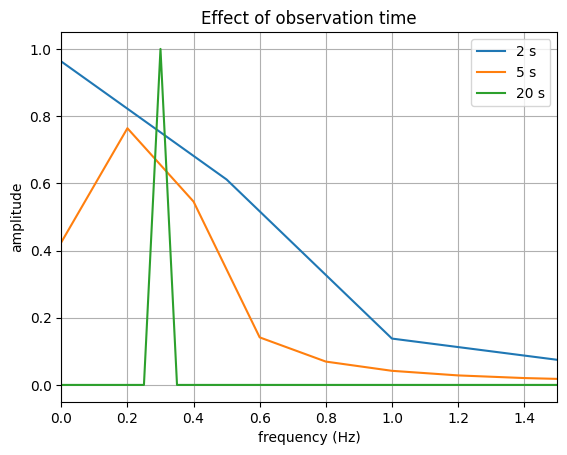

In [30]:
f_slow = 0.3

for duration_test in [2, 5, 20]:
    tt = np.arange(0, duration_test, 1/fs)
    yy = np.sin(2*np.pi*f_slow*tt)

    YY = np.fft.rfft(yy)
    ff = np.fft.rfftfreq(len(yy), d=1/fs)

    plt.plot(ff, 2*np.abs(YY)/len(yy), label=f"{duration_test} s")

plt.xlim(0, 1.5)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Effect of observation time")
plt.legend()
plt.grid()
plt.show()

### Exercise 5 — frequency resolution

Calculate $\Delta f$ for recording durations of

$$
2\,\mathrm{s},\quad 10\,\mathrm{s},\quad 60\,\mathrm{s}.
$$

Suppose two physiological rhythms occur at 0.20 Hz and 0.25 Hz.

Would you expect a 5-second measurement to separate them clearly?

What measurement duration would you choose?

# Sampling: how often must we measure?
A digital measurement records the signal only at discrete times.

If the sampling frequency is

$$
f_s,
$$

the largest frequency that can be represented correctly is the **Nyquist frequency**

$$
\boxed{f_N=\frac{f_s}{2}}.
$$

Therefore, to measure a signal with frequency $f$, we need at least

$$
f_s>2f.
$$

In practice, we normally sample considerably faster.

### Exercise 6 — sampling

A biological sensor samples at 10 samples per second.

1. What is its Nyquist frequency?
2. Can it correctly measure a 1.2 Hz heartbeat signal?
3. Can it correctly measure an 8 Hz oscillation?
4. What minimum sampling frequency would theoretically be required for an 8 Hz signal?

# The meaning of the complex Fourier spectrum

We have already introduced the Fourier transform in the analytical section.

Recall Euler's formula:

$$
e^{-i\omega t}
=
\cos(\omega t)-i\sin(\omega t).
$$

This explains why complex numbers are so useful in Fourier analysis: they combine sine and cosine components into a single compact expression.

The Fourier spectrum is generally complex. Its magnitude tells us **how strongly a frequency is present**, while its complex phase contains information about **where the oscillation is shifted in time**.

For most of the examples in this notebook we concentrate on the magnitude of the spectrum.

## Frequency $f$ and angular frequency $\omega$

Be careful: two conventions are commonly used.

Frequency in hertz:

$$
f=\frac{1}{T}
$$

and angular frequency:

$$
\omega=2\pi f.
$$

Thus

$$
\boxed{\omega=2\pi f}.
$$

In experimental spectra we often use $f$ in Hz.

In differential equations for oscillators, $\omega$ is often more convenient.

# Connection to the harmonic oscillator
In the ODE notebook we studied

$$
\ddot{x}+\omega_0^2x=0.
$$

Its solution is

$$
x(t)=A\cos(\omega_0t+\phi).
$$

This oscillator contains one characteristic frequency.

Its Fourier spectrum therefore has a sharp peak at

$$
f_0=\frac{\omega_0}{2\pi}.
$$

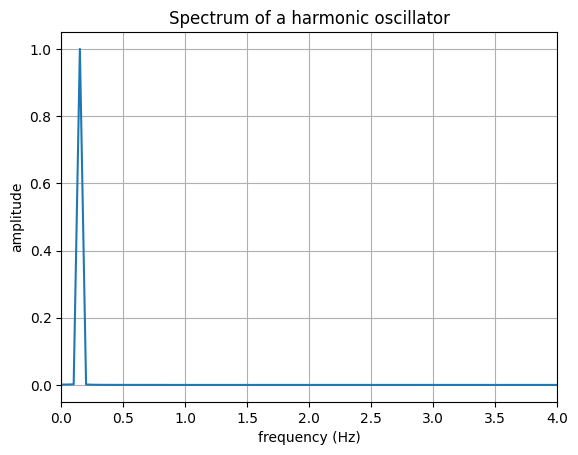

In [31]:
omega0 = 2*np.pi*1.5

oscillator = np.cos(omega0*t)

Y = np.fft.rfft(oscillator)
freq = np.fft.rfftfreq(len(oscillator), d=1/fs)

plt.plot(freq, 2*np.abs(Y)/len(oscillator))
plt.xlim(0, 4)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Spectrum of a harmonic oscillator")
plt.grid()
plt.show()

# What does damping do to the spectrum?
A damped oscillator has the form

$$
x(t)=A e^{-\delta t}\cos(\omega_dt).
$$

Unlike an ideal oscillator, it does not oscillate forever.

A signal that exists only for a limited time cannot have an infinitely sharp frequency.

Let us compare weak and strong damping.

In [ ]:
f0 = 1.5
omega = 2*np.pi*f0

weak = np.exp(-0.2*t)*np.cos(omega*t)
strong = np.exp(-1.0*t)*np.cos(omega*t)

for sig, label in [(weak, "weak damping"), (strong, "strong damping")]:
    Y = np.fft.rfft(sig)
    freq = np.fft.rfftfreq(len(sig), d=1/fs)
    plt.plot(freq, 2*np.abs(Y)/len(sig), label=label)

plt.xlim(0, 4)
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.title("Damping broadens the spectral peak")
plt.legend()
plt.grid()
plt.show()

The more rapidly the oscillation disappears in time, the broader its frequency spectrum becomes.

This is a useful general principle:

> **A long-lasting regular oscillation has a narrow spectrum. A short-lived oscillation has a broader spectrum.**

# Returning to biology: predator–prey oscillations
In the ODE notebook we introduced the Lotka–Volterra equations:

$$
\frac{dN}{dt}=aN-bNP,
$$

$$
\frac{dP}{dt}=cNP-dP.
$$

Here $N$ is the prey population and $P$ is the predator population.

The populations oscillate, but their time traces are not necessarily perfect sine waves.

Can Fourier analysis determine their characteristic oscillation frequency?

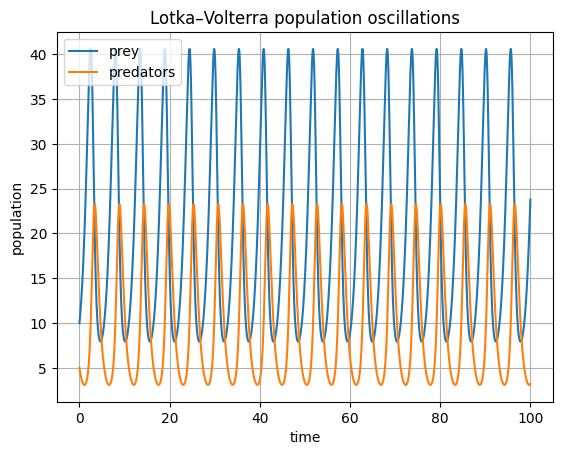

In [33]:
def rk4_system(f, y0, t):
    y = np.zeros((len(t), len(y0)), dtype=float)
    y[0] = y0

    for i in range(len(t)-1):
        h = t[i+1] - t[i]

        k1 = np.asarray(f(t[i], y[i]))
        k2 = np.asarray(f(t[i] + h/2, y[i] + h*k1/2))
        k3 = np.asarray(f(t[i] + h/2, y[i] + h*k2/2))
        k4 = np.asarray(f(t[i] + h, y[i] + h*k3))

        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6

    return y

a = 1.0
b = 0.1
c = 0.075
d = 1.5

def predator_prey(t, y):
    N, P = y
    return [
        a*N - b*N*P,
        c*N*P - d*P
    ]

dt_bio = 0.01
t_bio = np.arange(0, 100, dt_bio)

solution = rk4_system(predator_prey, [10, 5], t_bio)

N = solution[:, 0]
P = solution[:, 1]

plt.plot(t_bio, N, label="prey")
plt.plot(t_bio, P, label="predators")
plt.xlabel("time")
plt.ylabel("population")
plt.title("Lotka–Volterra population oscillations")
plt.legend()
plt.grid()
plt.show()

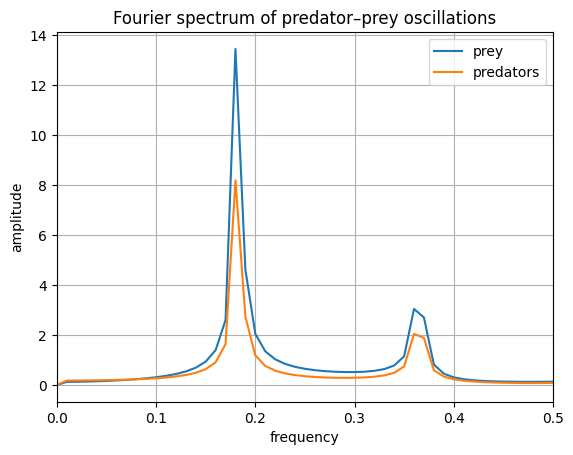

In [34]:
# Remove the mean before calculating the spectrum

N_centered = N - np.mean(N)
P_centered = P - np.mean(P)

YN = np.fft.rfft(N_centered)
YP = np.fft.rfft(P_centered)

freq_bio = np.fft.rfftfreq(len(N), d=dt_bio)

amp_N = 2*np.abs(YN)/len(N)
amp_P = 2*np.abs(YP)/len(P)

plt.plot(freq_bio, amp_N, label="prey")
plt.plot(freq_bio, amp_P, label="predators")
plt.xlim(0, 0.5)
plt.xlabel("frequency")
plt.ylabel("amplitude")
plt.title("Fourier spectrum of predator–prey oscillations")
plt.legend()
plt.grid()
plt.show()

The dominant peak gives the characteristic population-cycle frequency.

We can convert this frequency into a period using

$$
T=\frac{1}{f}.
$$

Thus the Fourier transform provides a systematic way of extracting a characteristic time scale from the numerical solution of an ODE.

In [35]:
# Find the strongest non-zero frequency in the prey spectrum

index = np.argmax(amp_N[1:]) + 1
dominant_frequency = freq_bio[index]
dominant_period = 1 / dominant_frequency

print(f"Dominant frequency = {dominant_frequency:.4f}")
print(f"Dominant period = {dominant_period:.2f} time units")

Dominant frequency = 0.1800
Dominant period = 5.56 time units


# Exercise 7 — Fourier analysis of a biological oscillator

Use the Lotka–Volterra simulation above.

### A. Determine the period in two ways

1. Estimate the period directly from the distance between successive maxima in $N(t)$.
2. Determine the dominant frequency from the Fourier spectrum.
3. Convert the frequency into a period using

$$
T=\frac{1}{f}.
$$

Compare the two results.

### B. Predator and prey

Calculate the Fourier spectra of both $N(t)$ and $P(t)$.

- Do they have the same dominant frequency?
- Should you expect them to?
- Their maxima occur at different times. Is this mainly a difference in frequency or in phase?

### C. Change the initial conditions

Repeat the calculation for

$$
(N_0,P_0)=(20,5).
$$

Does the dominant frequency remain exactly the same?

### D. Interpretation

Compare the Fourier spectrum of the Lotka–Volterra oscillation with that of a pure sine wave.

Is the biological oscillation perfectly sinusoidal? How can you tell from its spectrum?

# A circadian-rhythm exercise
Many biological processes vary approximately over a 24-hour cycle.

Suppose a measurement is described approximately by

$$
y(t)
=
10
+
2\cos\left(\frac{2\pi t}{24}\right)
+
0.5\cos\left(\frac{2\pi t}{12}\right),
$$

where $t$ is measured in hours.

### Exercise 8

1. What are the periods of the two oscillating components?
2. What are their frequencies in $\mathrm{h}^{-1}$?
3. Generate the signal for 7 days.
4. Plot the time signal.
5. Calculate its Fourier spectrum.
6. Identify the two peaks.
7. Why should you subtract the mean before plotting the spectrum?
8. What biological interpretation might a 12-hour harmonic have in a signal dominated by a 24-hour rhythm?

Use the following cell to begin.

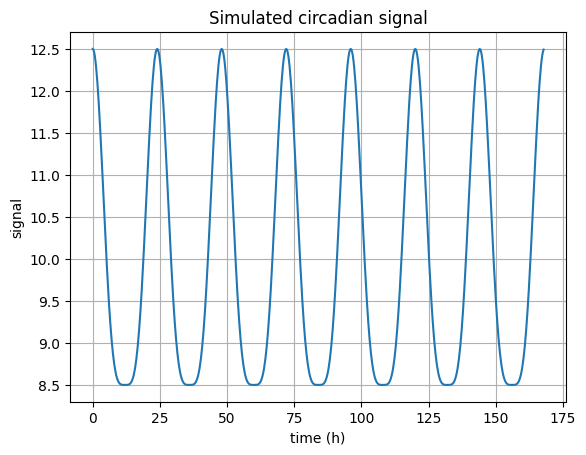

In [36]:
dt = 0.25                    # hours
t_day = np.arange(0, 7*24, dt)

circadian = (
    10
    + 2*np.cos(2*np.pi*t_day/24)
    + 0.5*np.cos(2*np.pi*t_day/12)
)

plt.plot(t_day, circadian)
plt.xlabel("time (h)")
plt.ylabel("signal")
plt.title("Simulated circadian signal")
plt.grid()
plt.show()

# Calculate and plot the Fourier spectrum below.

# Summary
A time-domain signal answers the question:

> **How does a quantity change with time?**

A Fourier spectrum answers a different question:

> **Which frequencies are contained in the signal, and how strongly?**

We have seen that Fourier analysis can reveal:

- heart rate,
- breathing rate,
- multiple rhythms hidden in one measurement,
- periodic signals in the presence of noise,
- harmonics of non-sinusoidal signals,
- characteristic frequencies of mechanical oscillators,
- characteristic periods of biological population oscillations.

The mathematical Fourier transform is

$$
F(\omega)
=
\int_{-\infty}^{\infty}
f(t)e^{-i\omega t}\,dt,
$$

but its central idea is simple:

> **A complicated signal can be understood as a combination of oscillations with different frequencies.**

This makes Fourier analysis a powerful link between mathematics, physics, biology, and experimental data analysis.

# Final conceptual questions

1. What is the difference between the time domain and the frequency domain?
2. What does a peak in a Fourier spectrum mean?
3. Why does a constant offset appear at zero frequency?
4. Why does a non-sinusoidal periodic signal contain harmonics?
5. Why do we need a sufficiently long measurement to resolve slow rhythms?
6. Why must the sampling frequency be sufficiently high?
7. What is the relationship between $f$ and $\omega$?
8. Why are complex numbers useful in Fourier analysis?
9. How can Fourier analysis help us interpret an ODE solution?
10. Give one biological measurement for which a Fourier spectrum might be more informative than the raw time trace.